# Defi EquiAlgo - modele corrige

## 1. Redefinition de la cible

`decision_octroi` est biaise : a cote R egale, le comite accorde nettement moins aux regions
eloignees. Il n'existe pas d'autre etiquette, et une heuristique inventee (ex. cote R seule)
serait elle-meme un parti pris non mesure.

On redefinit donc la cible **a partir des donnees du comite**, en ne retirant que l'effet de la region.

**Hypothese :** le comite est juste pour le groupe Centre. Le merite estime d'un candidat est la
probabilite d'octroi qu'il aurait eue s'il avait ete traite comme un candidat du Centre.

Methode (`cible.py`) : regression logistique de `decision_octroi` avec un indicateur `eloignee`
explicite, puis prediction avec `eloignee = 0`. `code_postal_3` est exclu, car il est determine par la
region et absorberait l'effet.

La cible est construite en deux temps : les sections 1.1 a 1.4 retirent la penalite regionale, puis la
section 1.5 calibre les autres criteres du comite contre l'etalon cache (sondes HxBuddy). La cible
retenue est `cible.score_merite`.

La cible est construite en deux temps : les sections 1.1 a 1.4 retirent la penalite regionale, puis la
section 1.5 calibre les autres criteres du comite contre l'etalon cache (sondes HxBuddy). La cible
retenue est `cible.score_merite`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from fairlearn.postprocessing import ThresholdOptimizer

from analyse import evaluer_auc
from cible import (
    ajouter_eloignee, ajuster_modele_decision, coefficients,
    score_contrefactuel, octroi_top_k, octroi_par_tranche_r,
)

demandes = pd.read_csv('data/donnees_demandes.csv')
candidats = pd.read_csv('data/candidats_evaluation.csv')
groupe_hist = np.where(ajouter_eloignee(demandes)['eloignee'] == 1, 'Eloignee', 'Centre')
groupe_cand = np.where(ajouter_eloignee(candidats)['eloignee'] == 1, 'Eloignee', 'Centre')

### 1.1 Le modele de decision reproduit-il le comite ?

AUC sur un decoupage 70/30 identique a la baseline (RF : ~0.946). Le modele lineaire doit capter
la logique du comite aussi bien que le RF pour que le contrefactuel soit credible.

In [2]:
train, test = train_test_split(
    demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi']
)
modele_valid = ajuster_modele_decision(train)
print(evaluer_auc(modele_valid, ajouter_eloignee(test), test['decision_octroi'],
                  groupes=groupe_hist[test.index]).round(4))

# Modele final, ajuste sur tout l'historique.
modele_decision = ajuster_modele_decision(demandes)
print()
print(coefficients(modele_decision).round(3))

global      0.9540
Centre      0.9530
Eloignee    0.9497
Name: auc, dtype: float64

num__cote_r_equivalent                     4.102
num__eloignee                             -1.072
num__heures_travail_semaine                0.750
num__revenu_familial_estime                0.749
cat__programme_etudes_Arts et lettres     -0.233
cat__programme_etudes_Sciences sociales   -0.220
cat__programme_etudes_Sciences            -0.192
cat__programme_etudes_Genie               -0.165
cat__programme_etudes_Sante               -0.153
num__distance_domicile_campus_km           0.128
num__premiere_generation_universitaire    -0.022
dtype: float64


In [3]:
# La penalite est-elle un simple decalage, ou les pentes different-elles selon le groupe ?
# (dans un groupe, `eloignee` est constant : son coefficient est nul)
for g in ['Centre', 'Eloignee']:
    c = coefficients(ajuster_modele_decision(demandes[groupe_hist == g]))
    print(f"{g:<9} cote R {c['num__cote_r_equivalent']:.3f}   revenu {c['num__revenu_familial_estime']:.3f}"
          f"   heures {c['num__heures_travail_semaine']:.3f}")

print()
print(demandes.groupby(groupe_hist)[['cote_r_equivalent', 'revenu_familial_estime',
                                     'heures_travail_semaine', 'distance_domicile_campus_km']].mean().round(1))

Centre    cote R 4.043   revenu 0.708   heures 0.624
Eloignee  cote R 4.064   revenu 0.734   heures 0.663

          cote_r_equivalent  revenu_familial_estime  heures_travail_semaine  \
Centre                 28.0                 76056.3                     9.0   
Eloignee               27.3                 56330.3                    13.0   

          distance_domicile_campus_km  
Centre                           19.8  
Eloignee                        221.5  


Les pentes sont quasi identiques d'un groupe a l'autre : le biais du comite est un **decalage
constant** applique aux regions eloignees, ce que le modele additif capture correctement.

Point d'attention : le revenu familial a un effet **positif** dans les deux groupes (les menages
plus aises obtiennent davantage). Ce n'est donc pas un proxy pur de la region, mais il penalise
indirectement les regions eloignees, dont le revenu moyen est plus faible. D'ou une variante qui
neutralise aussi le revenu (fixe a la mediane).

### 1.2 Effet sur l'historique : octroi a cote R egale

Taux d'octroi par tranche de cote R : comite, puis contrefactuel (top 40 %).

In [4]:
score_hist = score_contrefactuel(modele_decision, demandes)
octroi_hist = octroi_top_k(score_hist, taux=demandes['decision_octroi'].mean())

comparaison = pd.concat({
    'comite': octroi_par_tranche_r(demandes, demandes['decision_octroi']),
    'contrefactuel': octroi_par_tranche_r(demandes, octroi_hist),
}, axis=1)
print(comparaison.round(3))
print()
print('Taux par groupe, comite       :', pd.Series(demandes['decision_octroi'].values).groupby(groupe_hist).mean().round(3).to_dict())
print('Taux par groupe, contrefactuel:', pd.Series(octroi_hist).groupby(groupe_hist).mean().round(3).to_dict())

                  comite          contrefactuel         
                  Centre Eloignee        Centre Eloignee
cote_r_equivalent                                       
(0, 26]            0.020    0.005         0.001    0.001
(26, 27]           0.161    0.038         0.012    0.016
(27, 28]           0.316    0.100         0.065    0.157
(28, 29]           0.593    0.256         0.400    0.583
(29, 30]           0.849    0.568         0.883    0.943
(30, 32]           0.958    0.831         1.000    1.000
(32, 45]           0.998    0.986         1.000    1.000

Taux par groupe, comite       : {'Centre': 0.484, 'Eloignee': 0.273}
Taux par groupe, contrefactuel: {'Centre': 0.414, 'Eloignee': 0.378}


L'ecart global passe d'environ 21 points a environ 4 points ; le reste s'explique par la cote R
moyenne plus faible en region (27.3 contre 28.0).

A cote R egale, le contrefactuel favorise maintenant **legerement** les regions eloignees dans les
tranches 27 a 29. Ce n'est pas un artefact : le comite valorise les heures travaillees et la distance,
plus elevees en region (13 h contre 9 h, 222 km contre 20 km). Sa penalite regionale masquait ces
criteres. Le contrefactuel les applique tels quels ; savoir si ce sont des criteres de merite
legitimes est une question de gouvernance a trancher explicitement.

### 1.3 Triangulation sur les 4 000 candidats

L'etalon de reference est cache. On compare quatre cibles candidates ; si elles concordent
largement, le choix est robuste.

- **contrefactuel** : region neutralisee (cible initiale, avant la calibration de la section 1.5)
- **contrefactuel + revenu** : region et revenu neutralises
- **cote R seule** : heuristique la plus simple
- **RF + ThresholdOptimizer** : modele de base corrige par egalite des chances *mesuree contre
  `decision_octroi`* (comparateur ; budget non garanti)

In [5]:
cibles = {
    'contrefactuel': octroi_top_k(score_contrefactuel(modele_decision, candidats, reference=demandes)),
    'contrefactuel + revenu': octroi_top_k(score_contrefactuel(
        modele_decision, candidats, neutraliser=['revenu_familial_estime'], reference=demandes)),
    'cote R seule': octroi_top_k(candidats['cote_r_equivalent']),
}

# Comparateur : RF de base + ThresholdOptimizer (egalite des chances vs decision_octroi).
CATEGORIELLES_RF = ['programme_etudes', 'region_administrative', 'code_postal_3']
X_hist = pd.get_dummies(demandes.drop(columns=['id_candidat', 'decision_octroi']), columns=CATEGORIELLES_RF)
X_cand = pd.get_dummies(candidats.drop(columns=['id_candidat']), columns=CATEGORIELLES_RF
                        ).reindex(columns=X_hist.columns, fill_value=0)
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
rf.fit(X_hist, demandes['decision_octroi'])
to = ThresholdOptimizer(estimator=rf, constraints='true_positive_rate_parity',
                        predict_method='predict_proba', prefit=True)
to.fit(X_hist, demandes['decision_octroi'], sensitive_features=groupe_hist)
cibles['RF + ThresholdOptimizer'] = to.predict(X_cand, sensitive_features=groupe_cand, random_state=42)

resume = pd.DataFrame({
    nom: {'taux global': d.mean(),
          'taux Centre': d[groupe_cand == 'Centre'].mean(),
          'taux Eloignee': d[groupe_cand == 'Eloignee'].mean()}
    for nom, d in cibles.items()
}).T
print(resume.round(3))

noms = list(cibles)
accord = pd.DataFrame([[(cibles[a] == cibles[b]).mean() for b in noms] for a in noms],
                      index=noms, columns=noms)
print()
print('Accord entre cibles (proportion de decisions identiques)')
print(accord.round(3))

                         taux global  taux Centre  taux Eloignee
contrefactuel                  0.400        0.411          0.385
contrefactuel + revenu         0.400        0.392          0.412
cote R seule                   0.400        0.428          0.359
RF + ThresholdOptimizer        0.388        0.455          0.289

Accord entre cibles (proportion de decisions identiques)
                         contrefactuel  contrefactuel + revenu  cote R seule  \
contrefactuel                    1.000                   0.940         0.928   
contrefactuel + revenu           0.940                   1.000         0.941   
cote R seule                     0.928                   0.941         1.000   
RF + ThresholdOptimizer          0.918                   0.904         0.950   

                         RF + ThresholdOptimizer  
contrefactuel                              0.918  
contrefactuel + revenu                     0.904  
cote R seule                               0.950  
RF + Thresho

Les trois cibles construites concordent sur environ 93 a 94 % des candidats : le choix de la
cible ne se joue que sur une bande etroite autour du seuil. Le comparateur ThresholdOptimizer garde un
grand ecart de taux d'octroi (environ 46 % contre 29 %) : egaliser la TPR par rapport a
`decision_octroi` revient a egaliser la fidelite a un comite biaise, sans corriger le biais.

### 1.4 Limites

- L'hypothese « le comite est juste pour le Centre » n'est pas verifiable sans l'etalon ; elle est
  explicite et documentee, ce qui vaut mieux qu'une regle implicite.
- Le contrefactuel conserve les autres poids du comite (revenu, heures). La variante
  « + revenu » mesure la sensibilite du resultat a ce choix.
- Le comparateur ThresholdOptimizer egalise la TPR **par rapport a `decision_octroi`**, donc par
  rapport a une etiquette biaisee : il sert de reference, pas de cible.

### 1.5 Calibration contre l'etalon (sondes HxBuddy)

La soumission construite sur le contrefactuel ci-dessus obtient **92.38 %** d'exactitude contre l'etalon
cache. Elle concorde a 99.7 % avec sa cible : l'ecart restant vient de la definition de la cible.

`sondes_cible.ipynb` soumet des variantes qui ne changent qu'un element a la fois :

| Sonde | Exactitude HxBuddy | Conclusion |
|---|---|---|
| comite sans correction (`retrait = 0`) | 88.83 % | la correction regionale rapporte 3.55 points |
| contrefactuel (cible initiale) | 92.38 % | |
| + revenu x0 | 94.43 % | le revenu ne fait pas partie du merite (optimum du multiplicateur : -0.01) |
| + revenu x-1 (besoin financier) | 92.43 % | favoriser les bas revenus n'aide pas non plus |
| + heures x0, x0.5, x1.5 ou x2 | 90.88 a 93.88 % | le poids du comite pour les heures est le bon (optimum : 0.92) |
| **+ revenu x0, distance x0** | **94.58 %** | la distance, proxy pur de la region, n'en fait pas partie |
| + revenu x0, `retrait` 0.75 ou 1.25 | 94.48 et 93.73 % | optimum vers 0.86, gain negligeable |

**Cible retenue** (`cible.score_merite`) : penalite regionale entierement retiree, revenu et distance
neutralises, autres criteres du comite conserves. Le niveau de retrait est discute en section 2.2 :
HxBuddy ne mesure que l'utilite (15 points), alors que l'equite (20 points) depend de l'ecart
d'egalite des chances, qu'il ne montre pas.

In [6]:
from cible import PONDERATIONS_MERITE, score_merite

octroi_merite = octroi_top_k(score_merite(modele_decision, demandes), taux=demandes['decision_octroi'].mean())
print('Criteres neutralises :', PONDERATIONS_MERITE)
print()
print(pd.concat({
    'comite': octroi_par_tranche_r(demandes, demandes['decision_octroi']),
    'contrefactuel region seule': octroi_par_tranche_r(demandes, octroi_hist),
    'merite retenu': octroi_par_tranche_r(demandes, octroi_merite),
}, axis=1).round(3))
print()
print('Taux par groupe, merite retenu :', pd.Series(octroi_merite).groupby(groupe_hist).mean().round(3).to_dict())

Criteres neutralises : {'revenu_familial_estime': 0, 'distance_domicile_campus_km': 0}

                  comite          contrefactuel region seule           \
                  Centre Eloignee                     Centre Eloignee   
cote_r_equivalent                                                       
(0, 26]            0.020    0.005                      0.001    0.001   
(26, 27]           0.161    0.038                      0.012    0.016   
(27, 28]           0.316    0.100                      0.065    0.157   
(28, 29]           0.593    0.256                      0.400    0.583   
(29, 30]           0.849    0.568                      0.883    0.943   
(30, 32]           0.958    0.831                      1.000    1.000   
(32, 45]           0.998    0.986                      1.000    1.000   

                  merite retenu           
                         Centre Eloignee  
cote_r_equivalent                         
(0, 26]                   0.000    0.000  
(26, 27] 

**Lecture.**
- Les taux d'octroi des deux groupes deviennent egaux (40.2 % au Centre, 39.5 % en region). Une fois le
  revenu neutralise, les candidats eloignes ne sont plus penalises par leur revenu plus faible, et leurs
  heures travaillees (13 h contre 9 h) compensent leur cote R moyenne un peu plus basse.
- A cote R egale, les candidats eloignes passent donc devant : 70.5 % contre 33.4 % entre 28 et 29.
  L'etalon valorise les heures travaillees (les neutraliser coute 1.5 point d'exactitude), et c'est la
  ou les deux groupes different le plus apres la region.

## 2. Front de Pareto equite / utilite

On evalue toutes les methodes sur le decoupage 70/30 de la baseline. Les modeles sont ajustes sur
`train` uniquement. Chaque methode accorde la bourse aux 40 % meilleurs scores de `test`, donc le
budget est identique partout et seules les priorites changent.

**References de merite.** L'etalon cache est inconnu ; on mesure contre quatre references,
recalculees sur `test` avec le modele de `train` : `decision_octroi` (le comite), le **merite retenu**
(section 1.5), le contrefactuel de region seule (cible initiale) et la cote R seule.

**Equite** : ecart d'egalite des chances, soit la TPR Centre moins la TPR Eloignee
(`analyse.ecart_egalite_chances`), qui est la metrique du scoreur. **Utilite** : exactitude par
rapport a la reference.

In [7]:
from analyse import ecart_egalite_chances

groupe_tr, groupe_te = groupe_hist[train.index], groupe_hist[test.index]
references = {
    'comite (decision_octroi)': test['decision_octroi'].to_numpy(),
    'merite retenu': octroi_top_k(score_merite(modele_valid, test, reference=train)),
    'contrefactuel region seule': octroi_top_k(score_contrefactuel(modele_valid, test)),
    'cote R seule': octroi_top_k(test['cote_r_equivalent']),
}

def evaluer(decisions):
    """Ecart d'egalite des chances et exactitude contre chaque reference."""
    return {
        (nom, mesure): valeur
        for nom, y in references.items()
        for mesure, valeur in [('ecart', ecart_egalite_chances(y, decisions, groupe_te)),
                               ('exactitude', (decisions == y).mean())]
    }

# Modele de production (RF), ajuste sur train, tel qu'utilise par la baseline.
X_tr = pd.get_dummies(train.drop(columns=['id_candidat', 'decision_octroi']), columns=CATEGORIELLES_RF)
X_te = pd.get_dummies(test.drop(columns=['id_candidat', 'decision_octroi']), columns=CATEGORIELLES_RF
                      ).reindex(columns=X_tr.columns, fill_value=0)
rf_tr = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
rf_tr.fit(X_tr, train['decision_octroi'])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

### 2.1 Validation de la reference

Le scoreur annonce un ecart d'egalite des chances de **0.270** pour le modele de base, mesure contre
l'etalon cache. On mesure cet ecart contre chaque reference de deux facons : sur le decoupage 70/30, et
sur les 4 000 candidats avec la soumission gabarit de la baseline (RF ajuste sur tout l'historique),
qui est la mesure directement comparable au 0.270.

In [8]:
validation = pd.DataFrame({
    'RF sur test (70/30)': {nom: ecart_egalite_chances(y, rf_tr.predict(X_te), groupe_te)
                            for nom, y in references.items()},
    'gabarit sur les candidats': {
        nom: ecart_egalite_chances(y, rf.predict(X_cand), groupe_cand)
        for nom, y in {'merite retenu': octroi_top_k(score_merite(modele_decision, candidats, reference=demandes)),
                       'contrefactuel region seule': cibles['contrefactuel'],
                       'cote R seule': cibles['cote R seule']}.items()},
})
print(validation.round(3))
print('\nEcart annonce par le scoreur (etalon cache) : 0.270')

                            RF sur test (70/30)  gabarit sur les candidats
comite (decision_octroi)                  0.063                        NaN
merite retenu                             0.315                      0.298
contrefactuel region seule                0.264                      0.261
cote R seule                              0.238                      0.225

Ecart annonce par le scoreur (etalon cache) : 0.270


**Lecture.**
- Contre `decision_octroi`, le RF parait presque equitable (0.06) : il reproduit fidelement le comite.
- Sur les candidats, l'ecart du gabarit vaut 0.298 contre le merite retenu, 0.261 contre le
  contrefactuel de region seule et 0.225 contre la cote R seule. La cible initiale etait la plus proche
  du 0.270 annonce.
- Ce chiffre unique ne suffit pas a departager les references : les sondes HxBuddy mesurent l'accord
  avec l'etalon sur 4 000 decisions, et le merite retenu y gagne 2.2 points d'exactitude (94.58 % contre
  92.38 %). Les trois references situent l'ecart du modele de base entre 0.23 et 0.32 : un biais du meme
  ordre que celui que mesure le scoreur.

### 2.2 Balayage de la contrainte d'equite

Le parametre balaye est `retrait`, la fraction de la penalite regionale du comite retiree du score de
merite (revenu et distance neutralises) : 0 garde la penalite, 1 donne la cible retenue, et au-dela on
surcorrige. Comme le modele est lineaire en logit, chaque valeur correspond a un compromis precis.

Comparateurs, tous entraines sur `decision_octroi` :
- le RF de base (`predict`, comme en production) ;
- le RF corrige par `ThresholdOptimizer` (parite de TPR, post-traitement). Faire varier `tol` ne
  produit que deux points distincts, d'ou un point unique ;
- le RF reentraine par `ExponentiatedGradient` sous contrainte de parite de TPR, en balayant la borne
  `difference_bound` de 0.2 a 0.005.

Les deux methodes fairlearn produisent des decisions randomisees : leurs probabilites d'octroi sont
classees pour accorder exactement 40 %.

In [9]:
RETRAITS = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
balayage = pd.DataFrame({
    r: evaluer(octroi_top_k(score_contrefactuel(modele_valid, test, retrait=r, reference=train,
                                                ponderations=PONDERATIONS_MERITE)))
    for r in RETRAITS
}).T
balayage.index.name = 'retrait'

to_tr = ThresholdOptimizer(estimator=rf_tr, constraints='true_positive_rate_parity',
                           predict_method='predict_proba', prefit=True)
to_tr.fit(X_tr, train['decision_octroi'], sensitive_features=groupe_tr)
proba_to = to_tr._pmf_predict(X_te, sensitive_features=groupe_te)[:, 1]
# Departage les ex aequo de la randomisation par le score du RF.
octroi_to = octroi_top_k(proba_to + 1e-9 * rf_tr.predict_proba(X_te)[:, 1])

comparateurs = pd.DataFrame({
    'RF de base': evaluer(rf_tr.predict(X_te)),
    'RF + ThresholdOptimizer': evaluer(octroi_to),
}).T

pd.set_option('display.width', 200)
print(pd.concat([balayage, comparateurs]).round(3))

                        comite (decision_octroi)            merite retenu            contrefactuel region seule            cote R seule           
                                           ecart exactitude         ecart exactitude                      ecart exactitude        ecart exactitude
0.0                                        0.074      0.867         0.286      0.907                      0.224      0.911        0.209      0.931
0.25                                       0.011      0.871         0.231      0.925                      0.162      0.927        0.148      0.942
0.5                                       -0.051      0.869         0.151      0.951                      0.076      0.945        0.059      0.951
0.75                                      -0.121      0.862         0.071      0.977                     -0.006      0.953       -0.008      0.949
1.0                                       -0.168      0.851         0.000      1.000                     -0.059      0

In [10]:
from fairlearn.reductions import ExponentiatedGradient, TruePositiveRateParity

# Comparateur : reentrainement sous contrainte de parite de TPR (contre decision_octroi), en balayant
# la tolerance. Foret de 100 arbres : EG reentraine le modele a chaque iteration (environ 25 s par point).
BORNES_EG = [0.2, 0.1, 0.05, 0.02, 0.01, 0.005]
X_tr_eg, X_te_eg = X_tr.astype(float), X_te.astype(float)

resultats_eg = {}
for borne in BORNES_EG:
    eg = ExponentiatedGradient(
        RandomForestClassifier(n_estimators=100, min_samples_leaf=20, random_state=42, n_jobs=-1),
        constraints=TruePositiveRateParity(difference_bound=borne), eps=0.01, max_iter=50)
    eg.fit(X_tr_eg, train['decision_octroi'], sensitive_features=groupe_tr)
    # Probabilite d'octroi du melange de modeles, classee pour respecter le budget.
    resultats_eg[borne] = evaluer(octroi_top_k(eg._pmf_predict(X_te_eg)[:, 1]))

balayage_eg = pd.DataFrame(resultats_eg).T
balayage_eg.index.name = 'difference_bound'
print(balayage_eg.round(3))

                 comite (decision_octroi)            merite retenu            contrefactuel region seule            cote R seule           
                                    ecart exactitude         ecart exactitude                      ecart exactitude        ecart exactitude
difference_bound                                                                                                                           
0.200                               0.025      0.867         0.283      0.901                      0.227      0.909        0.202      0.935
0.100                              -0.001      0.869         0.253      0.909                      0.193      0.916        0.168      0.943
0.050                               0.026      0.866         0.285      0.900                      0.224      0.905        0.208      0.936
0.020                               0.035      0.866         0.285      0.901                      0.226      0.908        0.204      0.936
0.010               

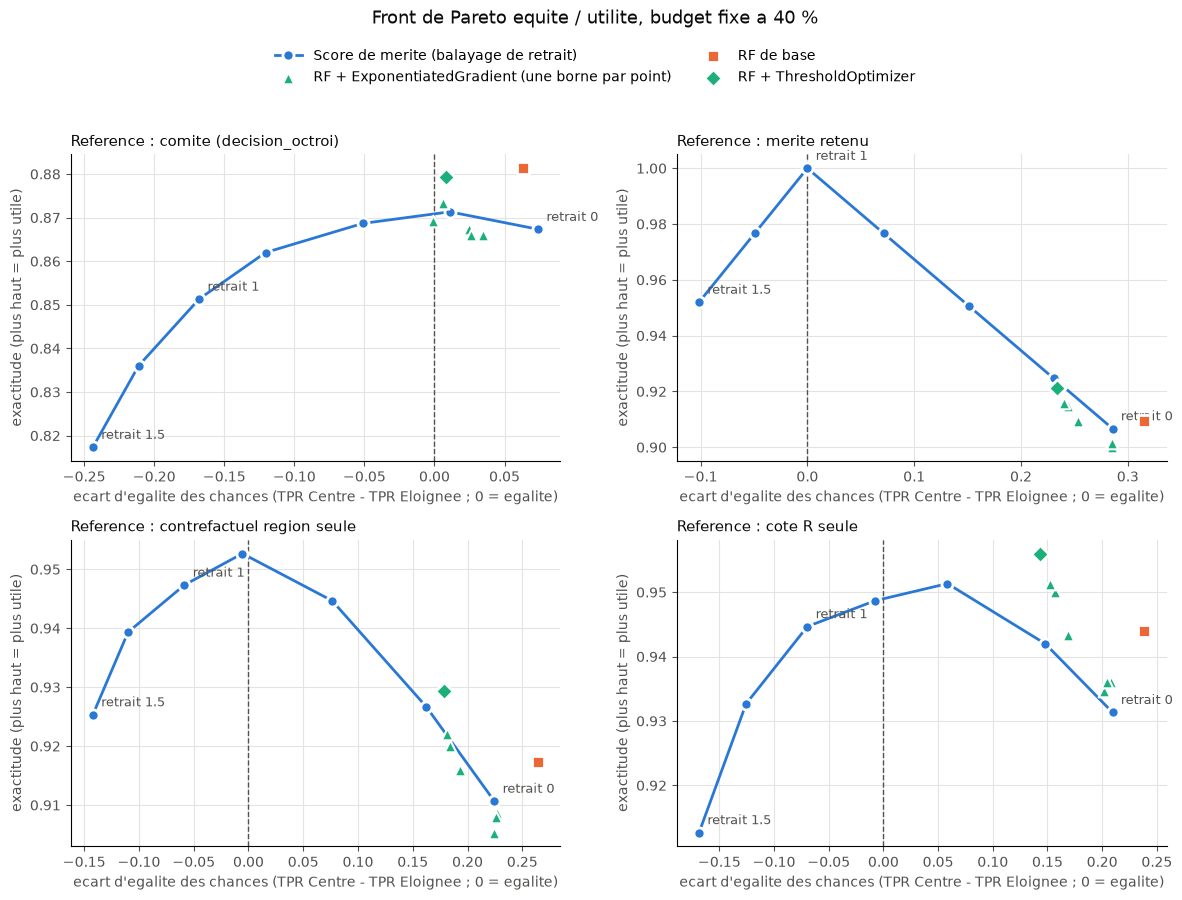

In [11]:
import matplotlib.pyplot as plt

# Palette categorielle de reference (slots 1-3, valides pour un nuage de points).
# Vert d'eau = les deux methodes fairlearn (contrainte contre decision_octroi), distinguees par la forme.
BLEU, ORANGE, VERT_EAU = '#2a78d6', '#eb6834', '#1baf7a'
ENCRE, ENCRE_SECONDAIRE, GRILLE = '#0b0b0b', '#52514e', '#e4e3df'

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, nom in zip(axes.flat, references):
    x, y = balayage[(nom, 'ecart')], balayage[(nom, 'exactitude')]
    ax.axvline(0, color=ENCRE_SECONDAIRE, lw=1, ls='--', zorder=1)
    ax.plot(x, y, '-o', color=BLEU, lw=2, ms=8, mec='white', mew=2,
            label='Score de merite (balayage de retrait)', zorder=3)
    for r in [0, 1.0, 1.5]:
        ax.annotate(f'retrait {r:g}', (x[r], y[r]), xytext=(6, 6), textcoords='offset points',
                    fontsize=9, color=ENCRE_SECONDAIRE)
    # Points non relies : le resultat d'EG n'est pas monotone en la borne.
    ax.scatter(balayage_eg[(nom, 'ecart')], balayage_eg[(nom, 'exactitude')], s=70, marker='^',
               color=VERT_EAU, edgecolor='white', linewidth=1.5, zorder=4,
               label='RF + ExponentiatedGradient (une borne par point)')
    for methode, couleur, forme in [('RF de base', ORANGE, 's'), ('RF + ThresholdOptimizer', VERT_EAU, 'D')]:
        ax.scatter(comparateurs.loc[methode, (nom, 'ecart')], comparateurs.loc[methode, (nom, 'exactitude')],
                   s=80, marker=forme, color=couleur, edgecolor='white', linewidth=2, zorder=4, label=methode)
    ax.set_title(f'Reference : {nom}', color=ENCRE, fontsize=11, loc='left')
    ax.set_xlabel('ecart d\'egalite des chances (TPR Centre - TPR Eloignee ; 0 = egalite)', color=ENCRE_SECONDAIRE)
    ax.set_ylabel('exactitude (plus haut = plus utile)', color=ENCRE_SECONDAIRE)
    ax.grid(color=GRILLE, lw=0.8)
    ax.set_axisbelow(True)
    for cote in ['top', 'right']:
        ax.spines[cote].set_visible(False)
    ax.tick_params(colors=ENCRE_SECONDAIRE)

poignees, etiquettes = axes.flat[0].get_legend_handles_labels()
fig.suptitle('Front de Pareto equite / utilite, budget fixe a 40 %', y=0.995, fontsize=13, color=ENCRE)
fig.legend(poignees, etiquettes, loc='upper center', bbox_to_anchor=(0.5, 0.965), ncol=2, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.91))
plt.show()

**Lecture.** Le point ideal est sur la ligne pointillee (ecart nul), le plus haut possible.
- Contre `decision_octroi`, retirer la penalite fait perdre de l'exactitude (de 0.867 a 0.851) : c'est le
  compromis « classique », mais il ne mesure que la fidelite au comite.
- Contre le merite retenu, le panneau est circulaire : `retrait = 1` y est parfait par construction.
- Contre les deux references independantes (contrefactuel de region seule, cote R seule), retirer la
  penalite ameliore a la fois l'equite et l'exactitude jusqu'a `retrait` d'environ 0.75 (ecart de
  -0.006 et -0.008). A 1, l'ecart devient negatif (-0.06 et -0.07) : il favorise legerement les regions
  eloignees.
- Contre la cote R seule, les RF sont plus exacts (0.94 a 0.96) mais gardent un ecart de 0.14 a 0.24.
- Les deux methodes fairlearn tiennent leur contrainte **contre `decision_octroi`** : 0.008 pour
  ThresholdOptimizer, -0.001 a 0.035 pour ExponentiatedGradient. Contre les references de merite, l'ecart
  reste de 0.14 a 0.29 : elles egalisent la fidelite a un comite biaise.
- Resserrer la borne d'ExponentiatedGradient ne fait presque rien : de 0.2 a 0.005, l'ecart contre le
  merite retenu ne passe que de 0.28 a 0.24, de facon non monotone. La contrainte est deja satisfaite
  contre l'etiquette biaisee ; la resserrer ne corrige pas le biais reel. C'est l'argument central pour
  corriger la **cible** plutot que contraindre le modele.

**Niveau de retrait.** Les indices divergent : 1 contre le merite retenu (circulaire), environ 0.86 pour
l'exactitude HxBuddy, environ 0.75 pour l'equite contre les references independantes. Si l'ecart est
mesure en valeur absolue, le pire ecart sur les trois references est minimal vers 0.875 (environ 0.03 a
0.04 partout), contre 0.07 a 1 et a 0.75. La soumission actuelle garde `retrait = 1`, le choix qui
correspond a l'hypothese explicite (« traiter chacun comme un candidat du Centre ») ; un retrait
d'environ 0.875 est l'alternative a considerer.

### 2.3 Soumission par score de merite (comparaison)

Le modele de decision est ajuste sur les 10 000 dossiers historiques (section 1). Les 4 000 candidats
sont classes par score de merite, et on accorde la bourse exactement a 40 %. C'est la sonde R2d de
`sondes_cible.ipynb` (94.58 % d'exactitude HxBuddy).

Ce score utilise la region au moment de la prediction (pour la neutraliser). La soumission officielle
vient du modele sans region de la section 3.3 ; celle-ci sert de comparaison.

In [12]:
predictions = octroi_top_k(score_merite(modele_decision, candidats, reference=demandes), taux=0.40)

taux = predictions.mean()
assert 0.36 <= taux <= 0.44, f'Hors budget : {taux:.1%}'
print(f'Taux d\'octroi : {taux:.1%}')
print(pd.Series(predictions).groupby(groupe_cand).mean().round(3).to_dict())

Taux d'octroi : 40.0%
{'Centre': 0.399, 'Eloignee': 0.401}


## 3. Modele entraine sur la nouvelle cible

Le score de merite est une **fonction deterministe des variables** : entrainer un modele a predire
`octroi_top_k(score_merite(...))` est circulaire (une regression logistique le retrouve avec une AUC de
1.0). Il faut une cible d'entrainement qui contienne de l'information propre a chaque dossier.

### 3.1 Cible individuelle

On garde la decision reelle du comite et on la corrige dossier par dossier (`cible.cible_individuelle`,
raisonnement par abduction). Avec p la probabilite d'octroi du comite et q le score de merite :

- comite a accorde : cible = min(1, q / p). Un candidat que son revenu avait aide peut descendre ;
- comite a refuse : cible = max(0, (q - p) / (1 - p)). Un candidat penalise par sa region peut monter ;
- en moyenne sur la decision du comite, la cible vaut exactement q.

La cible est souple (entre 0 et 1). On l'apprend par classification ponderee : chaque dossier est
duplique, etiquette 1 avec poids `cible` et etiquette 0 avec poids `1 - cible`.

Le modele n'utilise **ni la region, ni le code postal, ni la distance, ni le revenu**
(`cible.VARIABLES_MODELE`) : la cible a deja retire leur effet, et un modele de production ne doit pas
avoir besoin de l'attribut sensible ni de ses proxys.

In [13]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from cible import VARIABLES_MODELE, cible_individuelle, entrainer_modele_cible

cible_tr = cible_individuelle(modele_valid, train)
cible_te = cible_individuelle(modele_valid, test, reference=train)
print('Moyenne de la cible individuelle (train)')
print(pd.Series(cible_tr).groupby(groupe_tr).mean().round(3).to_dict(),
      ' contre decision_octroi :', train['decision_octroi'].groupby(groupe_tr).mean().round(3).to_dict())

Moyenne de la cible individuelle (train)
{'Centre': 0.478, 'Eloignee': 0.462}  contre decision_octroi : {'Centre': 0.484, 'Eloignee': 0.271}


### 3.2 Choix du modele

Trois familles, ajustees sur `train`, evaluees sur `test` :
- **AUC (cible individuelle)** : AUC ponderee contre la cible souple, la mesure d'ajustement ;
- **exactitude et ecart** contre les references de la section 2, apres octroi aux 40 % meilleurs.

In [14]:
CANDIDATS_MODELES = {
    'Regression logistique': LogisticRegression(max_iter=3000),
    'Foret aleatoire': RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1),
    'Gradient boosting': HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300,
                                                        min_samples_leaf=50, random_state=42),
}

n_te = len(test)
resultats, octrois_te = {}, {}
for nom, estimateur in CANDIDATS_MODELES.items():
    proba = entrainer_modele_cible(train, cible_tr, estimateur).predict_proba(test[VARIABLES_MODELE])[:, 1]
    octrois_te[nom] = octroi_top_k(proba)
    auc = roc_auc_score(np.r_[np.ones(n_te), np.zeros(n_te)], np.r_[proba, proba],
                        sample_weight=np.r_[cible_te, 1 - cible_te])
    resultats[nom] = {('cible individuelle', 'auc'): auc, **evaluer(octrois_te[nom])}

comparaison_modeles = pd.DataFrame(resultats).T
print(comparaison_modeles.round(3))

                      cible individuelle comite (decision_octroi)            merite retenu            contrefactuel region seule            cote R seule           
                                     auc                    ecart exactitude         ecart exactitude                      ecart exactitude        ecart exactitude
Regression logistique              0.953                   -0.164      0.851         0.002      0.999                     -0.055      0.947       -0.066      0.945
Foret aleatoire                    0.949                   -0.151      0.851         0.015      0.975                     -0.039      0.945       -0.059      0.948
Gradient boosting                  0.951                   -0.161      0.848        -0.015      0.980                     -0.059      0.942       -0.074      0.935


La regression logistique est le meilleur modele : la logique du comite est essentiellement additive
en logit (section 1.1), et les modeles flexibles n'ajoutent que de la variance. Elle reste aussi la
plus simple a expliquer et a auditer (un coefficient par variable), ce qui compte pour la gouvernance.

In [15]:
modele_final = entrainer_modele_cible(train, cible_tr)
noms = modele_final[0].get_feature_names_out()
print('Coefficients standardises du modele entraine (sans region)')
print(pd.Series(modele_final[-1].coef_[0], index=noms).sort_values(key=abs, ascending=False).round(3))

Coefficients standardises du modele entraine (sans region)
num__cote_r_equivalent                     4.065
num__heures_travail_semaine                0.733
cat__programme_etudes_Arts et lettres     -0.144
cat__programme_etudes_Sciences sociales   -0.097
num__premiere_generation_universitaire    -0.092
cat__programme_etudes_Genie               -0.014
cat__programme_etudes_Sante                0.013
cat__programme_etudes_Sciences             0.008
dtype: float64


### 3.3 Soumission finale

Le modele retenu est reajuste sur les 10 000 dossiers (cible calculee avec `modele_decision`), puis on
accorde la bourse aux 40 % meilleurs. C'est la soumission officielle : `predictions.csv` est ecrit ici.
On la compare a la soumission par score de merite de la section 2.3.

In [16]:
modele_cible = entrainer_modele_cible(demandes, cible_individuelle(modele_decision, demandes))
predictions_modele = octroi_top_k(modele_cible.predict_proba(candidats[VARIABLES_MODELE])[:, 1], taux=0.40)

soumission = pd.DataFrame({'id_candidat': candidats['id_candidat'], 'decision_octroi': predictions_modele})
assert len(soumission) == 4000 and soumission['id_candidat'].is_unique
assert set(soumission['decision_octroi']) <= {0, 1}
taux = soumission['decision_octroi'].mean()
assert 0.36 <= taux <= 0.44, f'Hors budget : {taux:.1%}'

soumission.to_csv('predictions.csv', index=False)
print(f'{len(soumission)} lignes ecrites dans predictions.csv, taux d\'octroi {taux:.1%}')
print(soumission.groupby(groupe_cand)['decision_octroi'].mean().round(3).to_dict())
print(f'Accord avec la soumission de la section 2.3 : {(predictions_modele == predictions).mean():.3f}')

4000 lignes ecrites dans predictions.csv, taux d'octroi 40.0%
{'Centre': 0.399, 'Eloignee': 0.402}
Accord avec la soumission de la section 2.3 : 0.999
